In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True)

    oof, pred, result_dict = cv_score.score()

    score = np.sqrt(mean_squared_error(y_true=target, y_pred=oof))
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.plot_regression_predictions(data=data, true_label=target, pred_label=oof, feature=["delta_Seed"])

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = np.sqrt(mean_squared_error(y_true=test_target, y_pred=pred))
        print(f"Test score: {score}")
        tml.plot_regression_predictions(data=test_data, true_label=test_target, pred_label=pred, feature=["delta_Seed"])

    return oof, pred, result_dict

In [3]:
df = pd.read_csv("data/processed/men_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

OOF score: 11.39818532815126
[8, 12, 47, 90, 16]


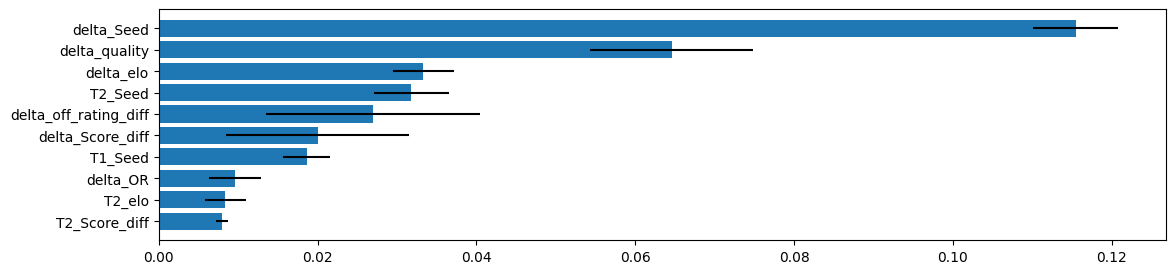

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


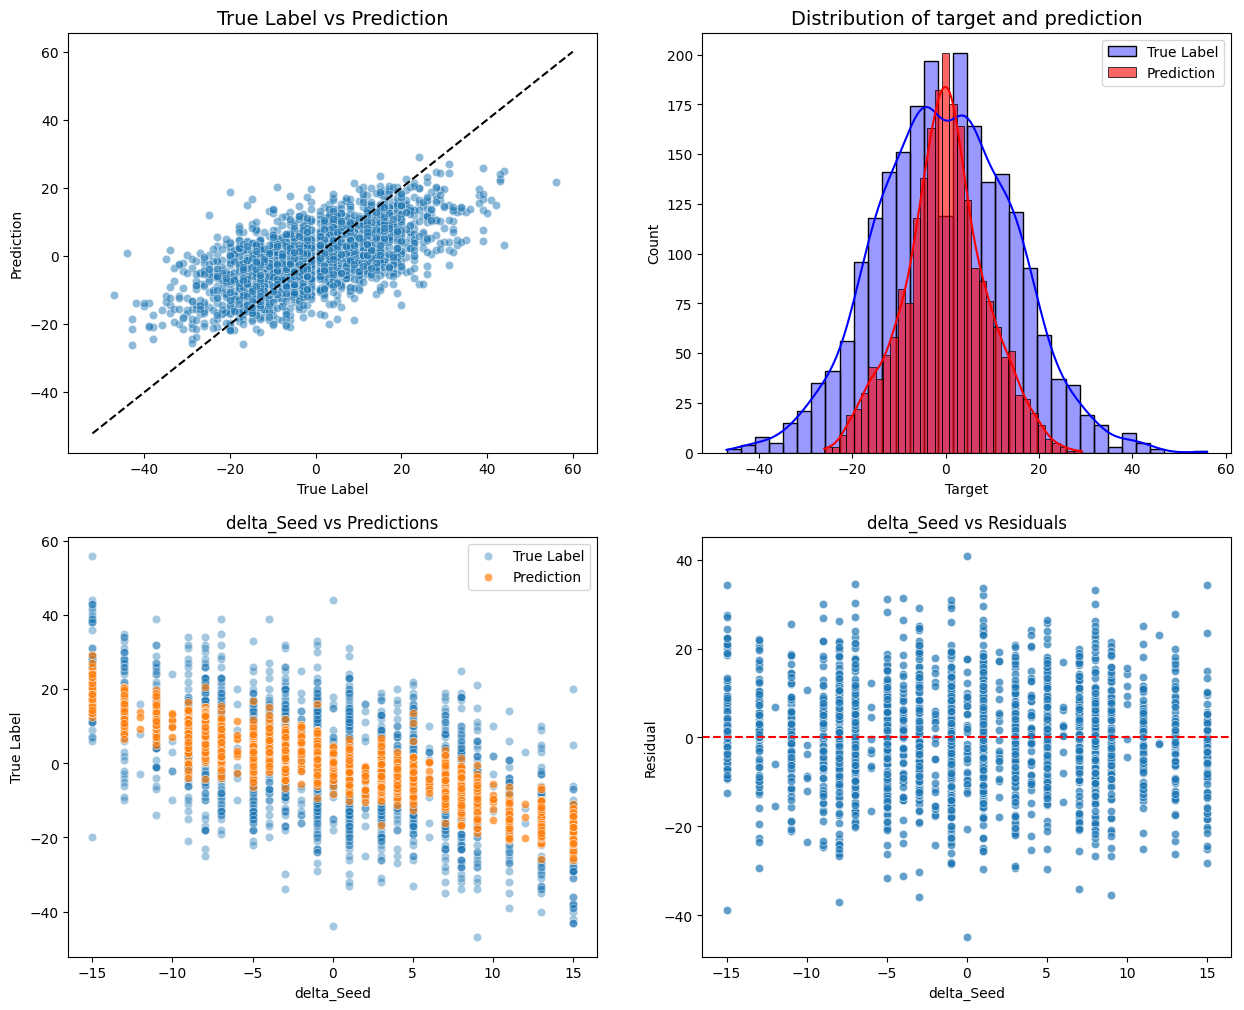

Test score: 12.041897957668054


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


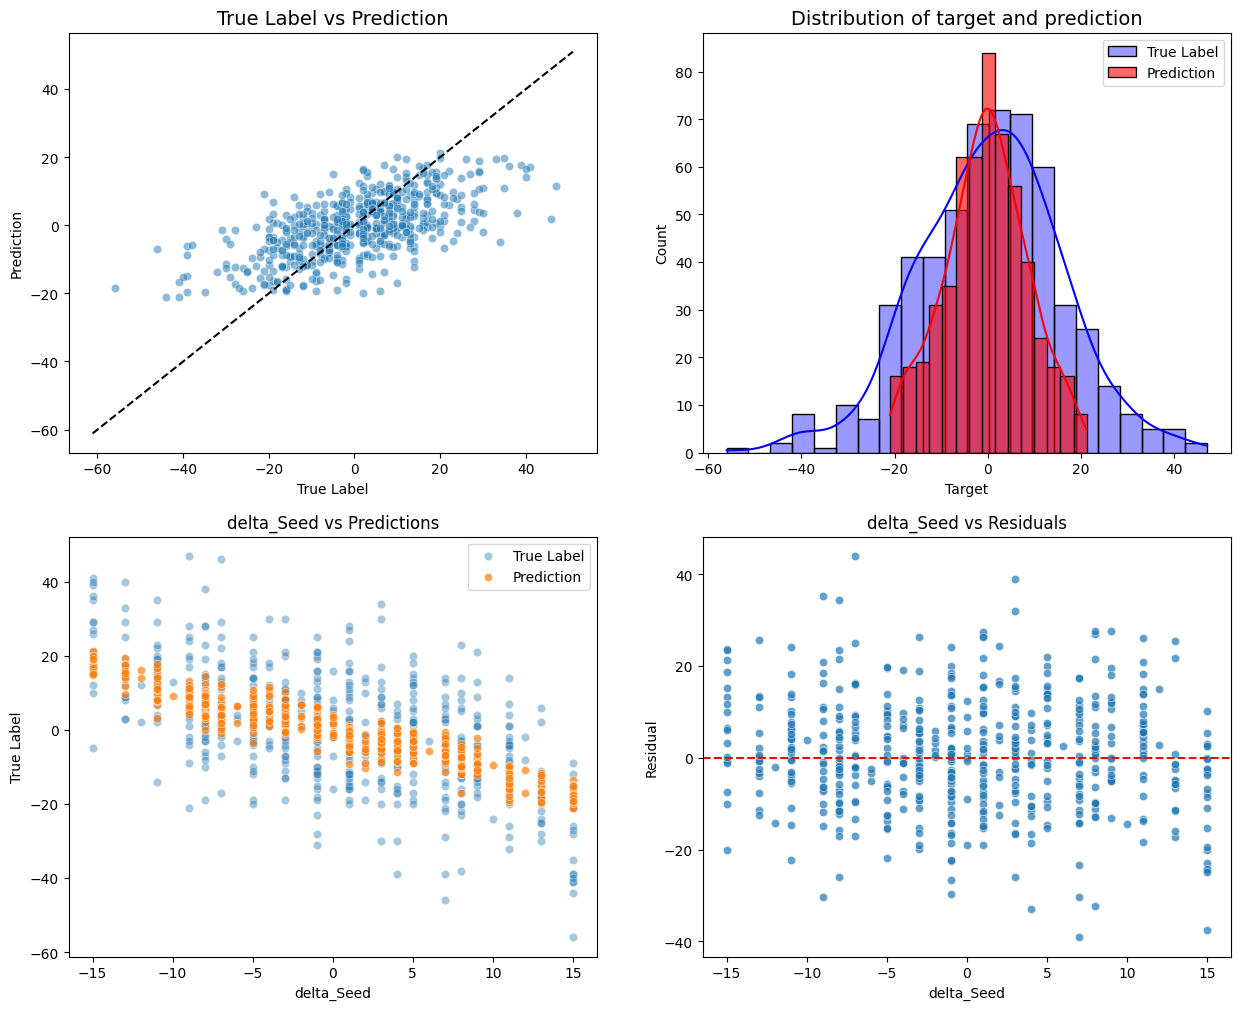

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


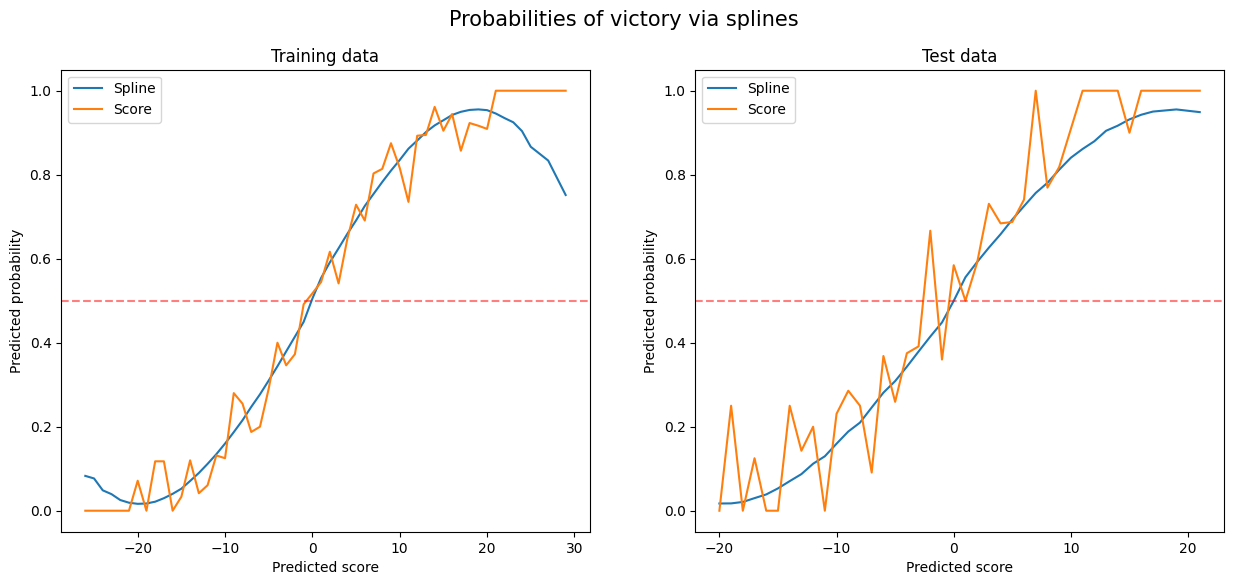

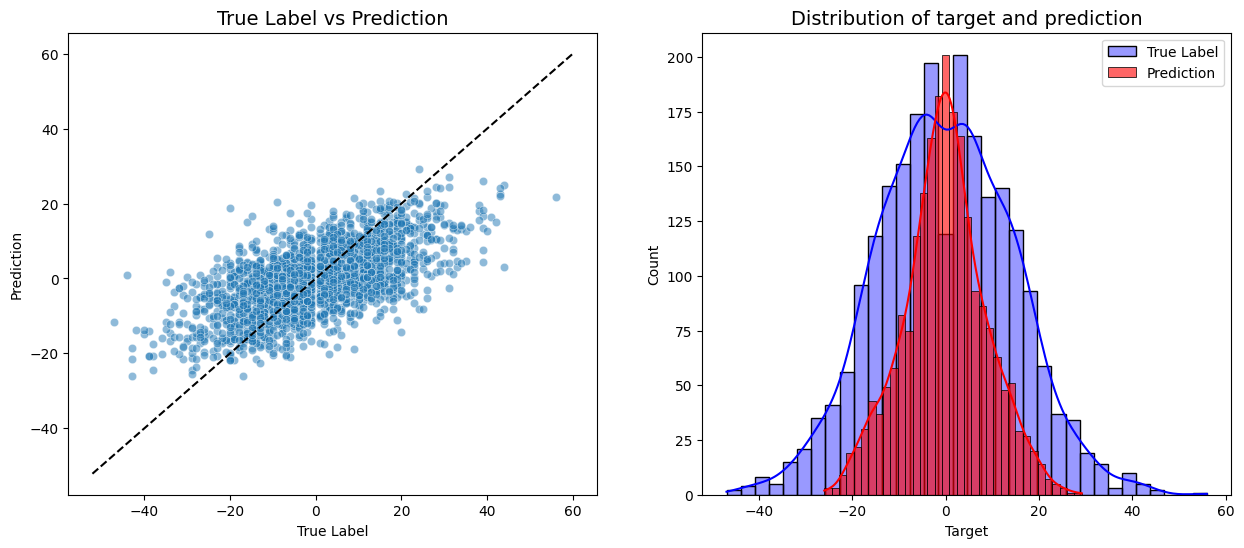

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


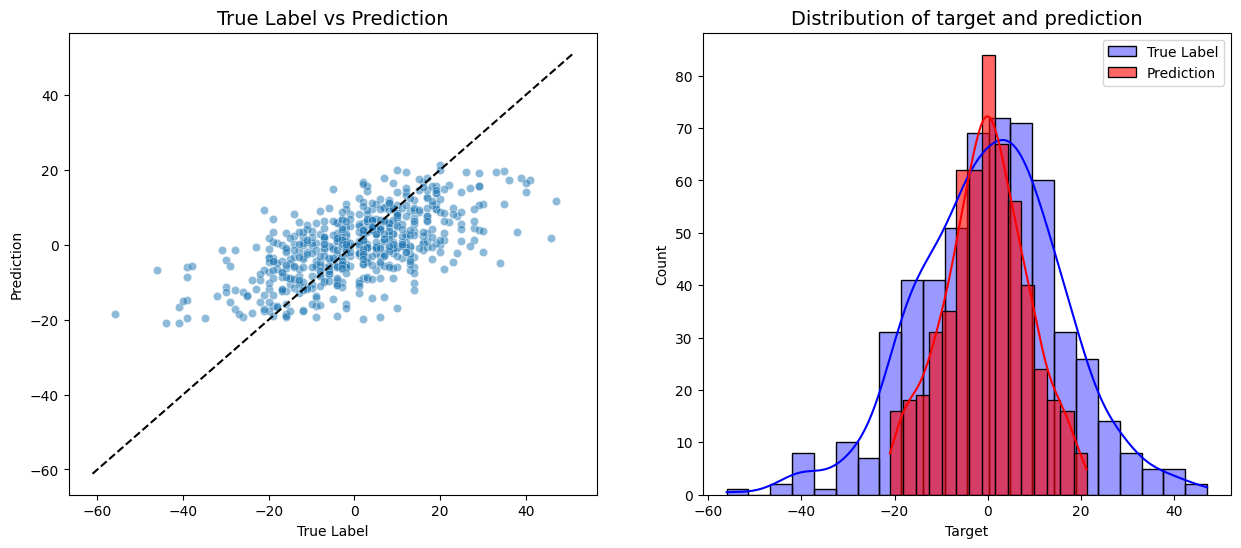

MAE train: 			 9.0414
MAE test: 			 9.2944
RMSE train: 			 11.3982
RMSE test: 			 12.0419
Accuracy train: 		 0.7093
Accuracy test: 			 0.7032
Logloss train: 			 0.5497
Logloss test: 			 0.539
Brier train: 			 0.186
Brier test: 			 0.1807
Unsure train: 			 21.42%
Unsure test: 			 20.5%


,mae_oof,mae_test,mse_oof,mse_test,acc_oof,acc_test,logloss_oof,logloss_test,brier_oof,brier_test,unsure_oof,unsure_test
0,9.0414,9.2944,11.3982,12.0419,0.7093,0.7032,0.5497,0.539,0.186,0.1807,21.42,20.5


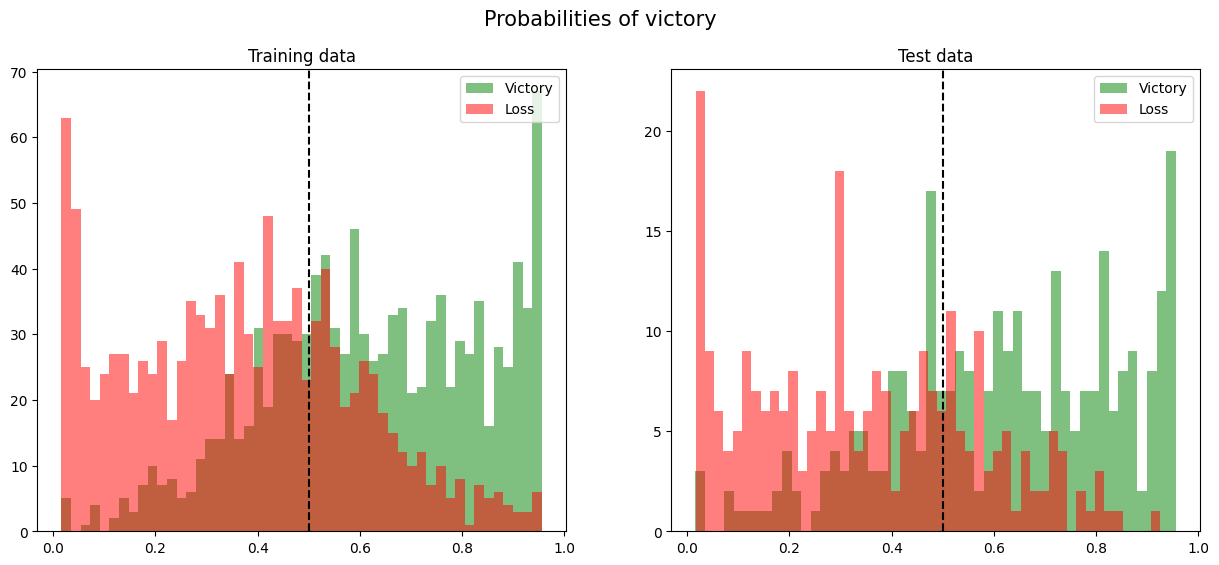

In [16]:
target = df_train["target_points"]

not_imp = [c for c in df_train if "stage" in c
 
] + [
 
 'T2_OR_opportunity',
 'T2_FGA_diff',
 'T2_FG3_ratio',
 'T1_opp_FGM3',
 'T2_Ast_TO_ratio_diff',
 'T1_FGM3_diff',
 'T2_FGM2',
 'T2_DR_opportunity',
 'T1_Ast_diff',
 'T2_Stl',
 'delta_Score',
 'T2_Eff_FG_perc_diff',
 'T1_OR_opportunity_diff',
 'delta_FTA',
 'T2_def_rating',
 'delta_OT_win_perc',
 'T2_FGA2_diff',
 'T1_OT_win_perc',
 'T1_True_shooting_perc',
 'T1_Stl_diff',
 'T2_Ast',
 'delta_OT_win',
 'T2_OR',
 'T2_FGM',
 'T2_TO_diff',
 'T2_OT_win_perc',
 'T1_opp_score',
 'delta_FG3_ratio',
 'delta_off_edge',
 'T2_FGA2',
 'T1_DR_opportunity_diff',
 'T1_TO',
 'T2_OR_opportunity_diff',
 'T1_FTA_diff',
 'delta_FGM2',
 'T1_Score',
 'delta_FGA2',
 'T2_OT_win',
 'T2_opp_FGM3',
 'T1_possessions',
 'T2_impact_diff',
 'T2_TO_perposs_diff',
 'T2_N_wins',
 'T2_TO_perposs',
 'delta_OR_diff',
 'delta_DR_opportunity',
 'T2_FGM2_perc',
 'delta_FTA_diff',
 'T1_OT_win',
 'T1_FGA3',
 'T1_FG3_ratio_diff',
 'delta_DR',
 'T2_FG3_ratio_diff',
 'T1_N_wins',
 'delta_FGA',
 'T2_Opp_eff_shooting_perc',
 'T1_FGM_diff',
 'delta_opp_possessions',
 'T2_FTM_diff',
 'delta_opp_TO',
 'delta_def_rating',
 'T2_Tot_Reb',
 'delta_opp_FGA',
 'T2_FTA_diff',
 'T1_Tot_Reb']

extras = ['T1_Seed',
 'T1_elo',
 'T2_Seed',
 'T2_elo',]
FEATURES = [c for c in df_train if  c not in DROP and c not in not_imp ] #+ extras
train = df_train[FEATURES].copy()
test_target = df_test["target_points"]
test = df_test[FEATURES].copy()

model = xgb.XGBRegressor(n_jobs=-1, random_state=34, n_estimators=10000,
                         max_depth=3,
                         reg_lambda=39.8, reg_alpha=85.8,
                         colsample_bytree=0.563,
                          colsample_bylevel=0.718,
                          subsample=0.765,
                         min_child_weight=53.36,
                         early_stopping_rounds=100,
                             eval_metric=mean_squared_error)

pipe = Pipeline([
                ('imputer', tml.DfImputer(strategy='mean')),
                ("model", model)])

    
fit_params = {"verbose": False}

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=fit_params, early_stopping=True,
                                       shap=False, result_compare=None)


report_points(train=df_train, test=df_test, y_train=target, y_test=test_target, oof=oof, preds=pred, clip_val=46, padd=0.013)

In [17]:
pred_oof, pred_test = _point_to_proba(oof=oof, y_train=df_train["target_points"], preds=pred, clip_val=46, padd=0.013)
df_train["oof"] = oof
df_train["oof_prob"] = pred_oof
df_test ["pred"] = pred
df_test["pred_prob"] = pred_test

df_train["abs_err_points"] = (df_train["target_points"] - df_train["oof"]).abs()
df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["abs_err_points"] = (df_test["target_points"] - df_test["pred"]).abs()
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [18]:
df_train.groupby("stage_Round1")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round1,,
False,9.225083,0.206825
True,8.862637,0.165729


In [19]:
df_train.groupby("stage_Round2")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round2,,
False,8.938656,0.184849
True,9.344210,0.189390


In [20]:
df_train.groupby("stage_Round3")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round3,,
False,9.012881,0.181276
True,9.239307,0.218762


In [21]:
df_train.groupby("stage_Round4")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_Round4,,
False,9.041084,0.181446
True,9.046353,0.254233


In [22]:
df_train.groupby("stage_finalfour")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_finalfour,,
False,9.026593,0.185447
True,9.471602,0.202035


In [23]:
df_train.groupby("stage_final")[["abs_err_points", "sqr_err_prob"]].mean()

,abs_err_points,sqr_err_prob
stage_final,,
False,9.057617,0.185757
True,7.998643,0.201585


In [29]:
thrs = np.arange(0, 25)

for th in thrs:
    tmp = df_train.copy()
    tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 + th / 100
    tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_final"]), "oof_prob"] = 0.5 - th / 100
    tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

    print(th, tmp["sqr_err_prob"].mean())

0 0.18599964561130136
1 0.18599829868875395
2 0.18599856871575665
3 0.18600509233502965
4 0.18600668881404084
5 0.18600843047341029
6 0.18601862688811685
7 0.18603727064809805
8 0.18605727021837828
9 0.18607645612706689
10 0.18608862165077458
11 0.1860966324518547
12 0.186106263414951
13 0.18611532683006674
14 0.1861249127886626
15 0.18613374310411732
16 0.18614717272435047
17 0.18616345522634553
18 0.18618277756676915
19 0.18619972942287455
20 0.1862191263625685
21 0.18623994901796234
22 0.18625865580759451
23 0.18627845778779253
24 0.18630114005601936


Round1 + 4%


In [30]:
tmp = df_train.copy()
print(tmp["sqr_err_prob"].mean())
tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + 4 / 100) & (tmp["stage_Round1"]), "oof_prob"] = 0.5 + 4 / 100
tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - 4 / 100) & (tmp["stage_Round1"]), "oof_prob"] = 0.5 - 4 / 100
tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2
tmp["sqr_err_prob"].mean()


0.18599964561130136


0.185925371489329

In [31]:
tmp = df_test.copy()
print(tmp["sqr_err_prob"].mean())
tmp.loc[(tmp["pred_prob"] > 0.5) & (tmp["pred_prob"] < 0.5 + 4 / 100) & (tmp["stage_Round1"]), "pred_prob"] = 0.5 + 4 / 100
tmp.loc[(tmp["pred_prob"] < 0.5) & (tmp["pred_prob"] > 0.5 - 4 / 100) & (tmp["stage_Round1"]), "pred_prob"] = 0.5 - 4 / 100
tmp["sqr_err_prob"] = (tmp["target"] - tmp["pred_prob"])**2
tmp["sqr_err_prob"].mean()

0.18070170994569443


0.18108261591113628

In [32]:
df_train.to_csv("data/results/men_train_xgb.csv", index=False)
df_test.to_csv("data/results/men_test_xgb.csv", index=False)